In [2]:
# Ejecutar solo si Java no está instalado.
# En Google Colab o Ubuntu puede ser necesario.

# !apt-get update
# !apt-get install -y openjdk-11-jdk


In [3]:
# Instalar dependencias Python.
# En un entorno local, ejecutar una vez desde consola:
# pip install python-terrier pandas matplotlib numpy

!pip install -q python-terrier pandas matplotlib numpy


  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.8/208.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.1/866.1 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.7/149.7 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 88.1 MB/s eta 0:00:00


In [4]:
import os
import re
import math
import tarfile
import shutil
from pathlib import Path
from collections import defaultdict
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pyterrier as pt

if not pt.java.started():
    pt.java.init()

print("PyTerrier inicializado correctamente")


terrier-assemblies 5.11 jar-with-dependencies not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-assemblies/5.11/terrier-assemblies-5.11-jar-with-dependenci…

Done
terrier-python-helper 0.0.8 jar not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-python-helper/0.0.8/terrier-python-helper-0.0.8.jar:   0%| …

Done
PyTerrier inicializado correctamente


Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]


## Descarga de la colección Vaswani



In [5]:

COLLECTION_URL = "https://raw.githubusercontent.com/tolosoft-academia/RI_2025/main/data/vaswani.tar.gz"

data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

archive_path = data_dir / "vaswani.tar.gz"
extract_dir = data_dir / "vaswani"

if not archive_path.exists():
    print("Descargando colección desde:", COLLECTION_URL)
    !wget -O {archive_path} {COLLECTION_URL}
else:
    print("Archivo ya descargado:", archive_path)

if extract_dir.exists():
    shutil.rmtree(extract_dir)

extract_dir.mkdir(parents=True, exist_ok=True)

with tarfile.open(archive_path, "r:gz") as tar:
    tar.extractall(extract_dir)

print("Colección extraída en:", extract_dir)
print("Archivos encontrados:")
for p in sorted(extract_dir.rglob("*"))[:20]:
    print(" -", p)

# Setea los diferentes archivos que se usaran (corpus, juicios de relevancia, queries)
def find_required_file(root: Path, filename: str) -> Path:
    matches = list(root.rglob(filename))
    if not matches:
        raise FileNotFoundError(f"No se encontró {filename} dentro de {root}")
    return matches[0]

doc_file = find_required_file(extract_dir, "doc-text.trec")
query_file = find_required_file(extract_dir, "query-text.trec")
qrels_file = find_required_file(extract_dir, "qrels")

print("Documentos:", doc_file)
print("Queries:", query_file)
print("Qrels:", qrels_file)


Descargando colección desde: https://raw.githubusercontent.com/tolosoft-academia/RI_2025/main/data/vaswani.tar.gz
--2026-05-02 19:36:22--  https://raw.githubusercontent.com/tolosoft-academia/RI_2025/main/data/vaswani.tar.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2049659 (2.0M) [application/octet-stream]
Saving to: ‘data/vaswani.tar.gz’

data/vaswani.tar.gz 100%[===================>]   1.95M  --.-KB/s    in 0.05s   

2026-05-02 19:36:22 (43.1 MB/s) - ‘data/vaswani.tar.gz’ saved [2049659/2049659]

Colección extraída en: data/vaswani
Archivos encontrados:
 - data/vaswani/vaswani
 - data/vaswani/vaswani/corpus
 - data/vaswani/vaswani/corpus/.complete
 - data/vaswani/vaswani/corpus/doc-text.trec
 - data/vaswani/vaswani/index
 - data/vaswani/vaswani/index

/tmp/ipykernel_21770/426863476.py:21: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_dir)


## Parseo documentos TREC



In [6]:
def parse_trec_docs(path: Path) -> pd.DataFrame:
    content = path.read_text(encoding="utf-8", errors="ignore")

    docs = []
    doc_blocks = re.findall(r"<DOC>(.*?)</DOC>", content, flags=re.S | re.I)

    for block in doc_blocks:
        docno_match = re.search(r"<DOCNO>\s*(.*?)\s*</DOCNO>", block, flags=re.S | re.I)
        text_match = re.search(r"<TEXT>\s*(.*?)\s*</TEXT>", block, flags=re.S | re.I)

        if not docno_match:
            continue

        docno = docno_match.group(1).strip()
        text = text_match.group(1).strip() if text_match else re.sub(r"<.*?>", " ", block)
        text = re.sub(r"\s+", " ", text).strip()

        docs.append({"docno": docno, "text": text})

    return pd.DataFrame(docs)

df_docs = parse_trec_docs(doc_file)
print("Documentos parseados:", len(df_docs))
df_docs.head()


Documentos parseados: 11429


,docno,text
0,1,1 compact memories have flexible capacities a ...
1,2,2 an electronic analogue computer for solving ...
2,3,3 electronic coordinate transformer circuit de...
3,4,4 the british computer society report of a con...
4,5,5 millimicrosecond digital computer logic a sy...


## Parseo de queries / necesidades de información


In [7]:
def clean_query_text(text: str, stopwords_list=None) -> str:
    if stopwords_list is None:
        stopwords_list = set(stopwords.words('english')) # Usar stopwords de NLTK por defecto

    text = text.lower()
    terms = re.findall(r"[a-z0-9]+", text)
    terms = [t for t in terms if t not in stopwords_list and len(t) > 1]
    return " ".join(terms)

def parse_trec_queries(path: Path) -> pd.DataFrame:
    content = path.read_text(encoding="utf-8", errors="ignore")
    topics = []

    # Formato TREC con <TOP>.
    top_blocks = re.findall(r"<top>(.*?)</top>", content, flags=re.S | re.I)
    if top_blocks:
        for block in top_blocks:
            qid_match = re.search(r"<num>\s*(?:Number:)?\s*(\d+)", block, flags=re.S | re.I)
            title_match = re.search(r"<title>\s*(.*?)(?=<desc>|<narr>|$)", block, flags=re.S | re.I)
            desc_match = re.search(r"<desc>\s*(?:Description:)?\s*(.*?)(?=<narr>|$)", block, flags=re.S | re.I)

            if qid_match:
                qid = qid_match.group(1).strip()
                raw = title_match.group(1).strip() if title_match else ""
                if not raw and desc_match:
                    raw = desc_match.group(1).strip()
                topics.append({"qid": qid, "need": re.sub(r"\s+", " ", raw)})

    # Formato tipo <DOC>.
    if not topics:
        doc_blocks = re.findall(r"<DOC>(.*?)</DOC>", content, flags=re.S | re.I)
        for block in doc_blocks:
            qid_match = re.search(r"<DOCNO>\s*(.*?)\s*</DOCNO>", block, flags=re.S | re.I)
            text_match = re.search(r"<TEXT>\s*(.*?)\s*</TEXT>", block, flags=re.S | re.I)
            if qid_match and text_match:
                topics.append({"qid": qid_match.group(1).strip(), "need": re.sub(r"\s+", " ", text_match.group(1).strip())})

    # Formato clásico .I / .W
    if not topics:
        blocks = re.split(r"\n\.I\s+", "\n" + content)
        for block in blocks:
            block = block.strip()
            if not block:
                continue
            qid, _, rest = block.partition("\n")
            text = re.sub(r"\.W", " ", rest).strip()
            topics.append({"qid": qid.strip(), "need": re.sub(r"\s+", " ", text)})

    df = pd.DataFrame(topics)
    df["qid"] = df["qid"].astype(str)
    df["query"] = df["need"].apply(clean_query_text)
    return df

topics = parse_trec_queries(query_file)

# Diccionario opcional para ajustar consultas manualmente.
# Ejemplo: query_overrides = {"1": "measurement dielectric constant liquids"}
# query_overrides = {}
#
# for qid, query in query_overrides.items():
#     topics.loc[topics["qid"] == str(qid), "query"] = query

print("Consultas parseadas (con stopwords de NLTK):", len(topics))
topics.head(10)


Consultas parseadas (con stopwords de NLTK): 93


,qid,need,query
0,1,MEASUREMENT OF DIELECTRIC CONSTANT OF LIQUIDS ...,measurement dielectric constant liquids use mi...
1,2,MATHEMATICAL ANALYSIS AND DESIGN DETAILS OF WA...,mathematical analysis design details waveguide...
2,3,USE OF DIGITAL COMPUTERS IN THE DESIGN OF BAND...,use digital computers design band pass filters...
3,4,SYSTEMS OF DATA CODING FOR INFORMATION TRANSFE...,systems data coding information transfer title
4,5,USE OF PROGRAMS IN ENGINEERING TESTING OF COMP...,use programs engineering testing computers title
5,6,NUMBER REPRESENTATION IN BINARY MACHINES </title>,number representation binary machines title
6,7,SECONDARY EMISSION OF ELECTRONS BY POSITIVE IO...,secondary emission electrons positive ion bomb...
7,8,MEASUREMENT OF PLASMA TEMPERATURES IN ARC DISC...,measurement plasma temperatures arc discharge ...
8,9,CHARACTERISTICS OF THE SINGLE ELECTRODE DISCHA...,characteristics single electrode discharge rar...
9,10,METHODS OF CALCULATING INSTANTANEOUS POWER DIS...,methods calculating instantaneous power dissip...


## Carga de juicios de relevancia


In [8]:
def read_qrels(path: Path) -> pd.DataFrame:
    rows = []
    with path.open(encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) >= 4:
                qid, _, docno, label = parts[:4]
            elif len(parts) == 3:
                qid, docno, label = parts
            else:
                continue
            rows.append({"qid": str(qid), "docno": str(docno), "label": int(float(label))})
    return pd.DataFrame(rows)

qrels = read_qrels(qrels_file)
print("Juicios de relevancia:", len(qrels))
qrels.head()


Juicios de relevancia: 2083


,qid,docno,label
0,1,1239,1
1,1,1502,1
2,1,4462,1
3,1,4569,1
4,1,5472,1


In [9]:
# Filtrar topics para quedarnos con queries que tengan qrels.
qids_with_qrels = set(qrels["qid"].astype(str))
topics_eval = topics[topics["qid"].isin(qids_with_qrels)].copy()

print("Consultas totales:", len(topics))
print("Consultas con qrels:", len(topics_eval))
topics_eval.head()


Consultas totales: 93
Consultas con qrels: 93


,qid,need,query
0,1,MEASUREMENT OF DIELECTRIC CONSTANT OF LIQUIDS ...,measurement dielectric constant liquids use mi...
1,2,MATHEMATICAL ANALYSIS AND DESIGN DETAILS OF WA...,mathematical analysis design details waveguide...
2,3,USE OF DIGITAL COMPUTERS IN THE DESIGN OF BAND...,use digital computers design band pass filters...
3,4,SYSTEMS OF DATA CODING FOR INFORMATION TRANSFE...,systems data coding information transfer title
4,5,USE OF PROGRAMS IN ENGINEERING TESTING OF COMP...,use programs engineering testing computers title


## Indexación con PyTerrier


In [10]:
import os

index_dir = Path(os.path.abspath("vaswani_index"))

if index_dir.exists():
    shutil.rmtree(index_dir)

index_dir.mkdir(parents=True, exist_ok=True)

indexer = pt.IterDictIndexer(
    str(index_dir),
    overwrite=True,
    meta={"docno": 64}
)

indexref = indexer.index(df_docs[["docno", "text"]].to_dict(orient="records"))

print("Índice creado en:", indexref)

Índice creado en: <org.terrier.querying.IndexRef at 0x7a73c1f1fed0 jclass=org/terrier/querying/IndexRef jself=<LocalRef obj=0x425dbdd0 at 0x7a7442b97fd0>>


In [11]:
index = pt.IndexFactory.of(indexref)
print(index.getCollectionStatistics().toString())


Number of documents: 11429
Number of terms: 17746
Number of postings: 234563
Number of fields: 0
Number of tokens: 281571
Field names: []
Positions:   false



## Recuperación (modelo vectorial TF-IDF)


In [12]:
tfidf = pt.terrier.Retriever(indexref, wmodel="TF_IDF", num_results=1000)

results = tfidf.transform(topics_eval[["qid", "query"]])
results["qid"] = results["qid"].astype(str)
results["docno"] = results["docno"].astype(str)

print("Resultados recuperados:", len(results))
results.head(10)


Resultados recuperados: 91953


,qid,docid,docno,rank,score,query
0,1,8171,8172,0,13.669276,measurement dielectric constant liquids use mi...
1,1,5501,5502,1,12.187393,measurement dielectric constant liquids use mi...
2,1,9880,9881,2,12.171401,measurement dielectric constant liquids use mi...
3,1,1501,1502,3,10.792411,measurement dielectric constant liquids use mi...
4,1,9858,9859,4,10.313025,measurement dielectric constant liquids use mi...
5,1,4870,4871,5,9.907501,measurement dielectric constant liquids use mi...
6,1,4816,4817,6,9.589195,measurement dielectric constant liquids use mi...
7,1,7233,7234,7,9.579081,measurement dielectric constant liquids use mi...
8,1,8275,8276,8,9.463080,measurement dielectric constant liquids use mi...
9,1,7922,7923,9,9.231094,measurement dielectric constant liquids use mi...


## Metricas





In [13]:
STANDARD_RECALL_LEVELS = np.round(np.linspace(0, 1, 11), 1)

def build_qrels_dict(qrels_df: pd.DataFrame):
    rel = defaultdict(dict)
    for row in qrels_df.itertuples(index=False):
        rel[str(row.qid)][str(row.docno)] = int(row.label)
    return rel

def dcg_at_k(gains, k=10):
    gains = gains[:k]
    return sum(g / math.log2(i + 2) for i, g in enumerate(gains))

# calcula metricas para un solo ranking de una query
def evaluate_one_query(qid: str, ranked_docs: list, rel_docs: dict, k=10):
    total_relevant = sum(1 for v in rel_docs.values() if v > 0)

    if total_relevant == 0:
        return {
            "qid": qid,
            "P@10": np.nan,
            "AP": np.nan,
            "nDCG@10": np.nan,
            **{f"RP@{level:.1f}": np.nan for level in STANDARD_RECALL_LEVELS}
        }

    # P@10
    top10 = ranked_docs[:10]
    p10 = sum(1 for d in top10 if rel_docs.get(d, 0) > 0) / 10

    # AP y puntos precision-recall
    num_rel_found = 0
    precision_sum = 0.0
    pr_points = []

    for rank, docno in enumerate(ranked_docs, start=1):
        is_rel = rel_docs.get(docno, 0) > 0
        # Si es un ranking con un doc rel recuperado
        if is_rel:
            num_rel_found += 1
            # calcula precision y recall en ese ranking
            precision_at_rank = num_rel_found / rank
            recall_at_rank = num_rel_found / total_relevant
            # suma para el promedio
            precision_sum += precision_at_rank
            # array para 11 niveles standar de recall
            pr_points.append((recall_at_rank, precision_at_rank))
    # AP
    ap = precision_sum / total_relevant

    # nDCG@10
    gains = [1 if rel_docs.get(d, 0) > 0 else 0 for d in ranked_docs[:10]]
    dcg10 = dcg_at_k(gains, 10)
    ideal_gains = [1] * min(total_relevant, 10)
    idcg10 = dcg_at_k(ideal_gains, 10)
    ndcg10 = dcg10 / idcg10 if idcg10 > 0 else np.nan

    # Recall-Precision interpolada en 11 puntos.
    interp = {}
    for level in STANDARD_RECALL_LEVELS:
        candidates = [p for r, p in pr_points if r >= level]
        interp[f"RP@{level:.1f}"] = max(candidates) if candidates else 0.0

    return {
        "qid": qid,
        "P@10": p10,
        "AP": ap,
        "nDCG@10": ndcg10,
        **interp
    }

# Para todas las queries, ordena su ranking y obtiene todas las metricas pedidas.
def evaluate_run(results_df: pd.DataFrame, qrels_dict: dict) -> pd.DataFrame:
    rows = []

    for qid in sorted(set(results_df["qid"].astype(str)), key=lambda x: int(x) if x.isdigit() else x):
        ranked_docs = (
            results_df[results_df["qid"] == qid]
            .sort_values("rank")
            ["docno"]
            .astype(str)
            .tolist()
        )
        rows.append(evaluate_one_query(qid, ranked_docs, qrels_dict.get(qid, {})))

    return pd.DataFrame(rows)


qrels_dict = build_qrels_dict(qrels)
eval_by_query = evaluate_run(results, qrels_dict)
eval_by_query.head()


,qid,P@10,AP,nDCG@10,RP@0.0,RP@0.1,RP@0.2,RP@0.3,RP@0.4,RP@0.5,RP@0.6,RP@0.7,RP@0.8,RP@0.9,RP@1.0
0,1,0.5,0.288936,0.602506,1.000000,1.000000,0.800000,0.333333,0.100000,0.100000,0.087591,0.085366,0.052288,0.034286,0.000000
1,2,0.1,0.063585,0.110046,0.333333,0.095238,0.058824,0.058824,0.058824,0.053571,0.053571,0.042636,0.039514,0.016092,0.000000
2,3,0.3,0.227950,0.318794,0.600000,0.360000,0.360000,0.291667,0.291667,0.274194,0.168067,0.130890,0.082317,0.062762,0.000000
3,4,0.3,0.493529,0.654809,1.000000,1.000000,1.000000,0.750000,0.750000,0.750000,0.750000,0.028249,0.028249,0.028249,0.028249
4,5,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## Evaluacion global


In [14]:
global_metrics = eval_by_query[["P@10", "AP", "nDCG@10"]].mean().to_frame(name="valor_promedio")
global_metrics


,valor_promedio
P@10,0.358065
AP,0.290498
nDCG@10,0.443631


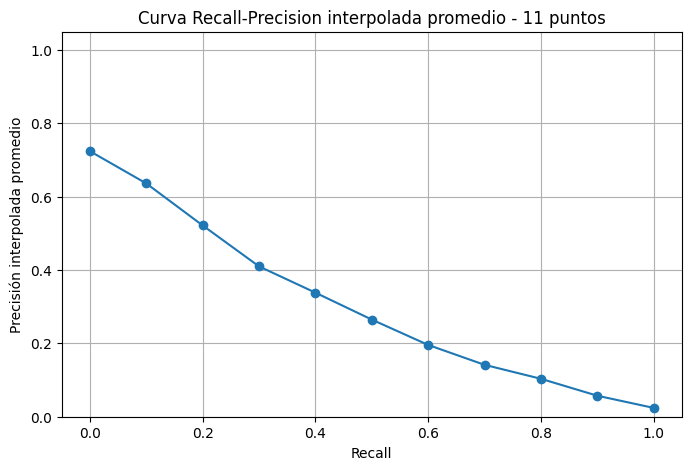

In [15]:
# Grafica 11 niveles estandar
rp_cols = [f"RP@{level:.1f}" for level in STANDARD_RECALL_LEVELS]
mean_rp = eval_by_query[rp_cols].mean()

global_rp = pd.DataFrame({
    "recall": STANDARD_RECALL_LEVELS,
    "precision_interpolada_promedio": mean_rp.values
})

plt.figure(figsize=(8, 5))
plt.plot(global_rp["recall"], global_rp["precision_interpolada_promedio"], marker="o")
plt.title("Curva Recall-Precision interpolada promedio - 11 puntos")
plt.xlabel("Recall")
plt.ylabel("Precisión interpolada promedio")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()


## Evaluación individual


In [16]:
# Estadísticos por métrica.
eval_by_query[["P@10", "AP", "nDCG@10"]].describe()


,P@10,AP,nDCG@10
count,93.000000,93.000000,93.000000
mean,0.358065,0.290498,0.443631
std,0.249488,0.177967,0.272145
min,0.000000,0.000000,0.000000
25%,0.200000,0.120597,0.224006
50%,0.300000,0.284783,0.485814
75%,0.500000,0.433246,0.646119
max,0.900000,0.722503,0.936379


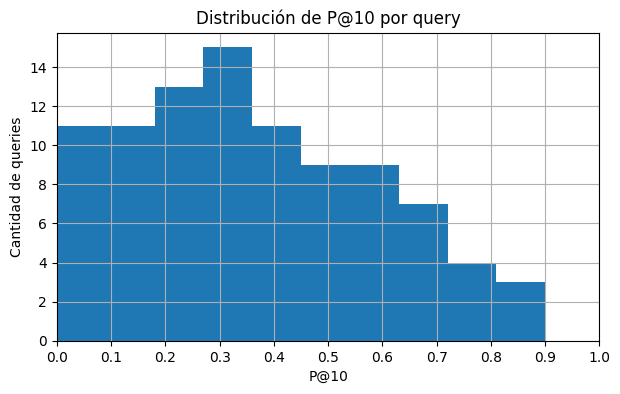

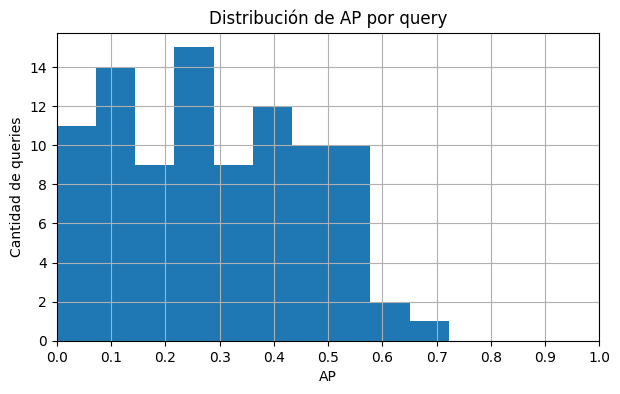

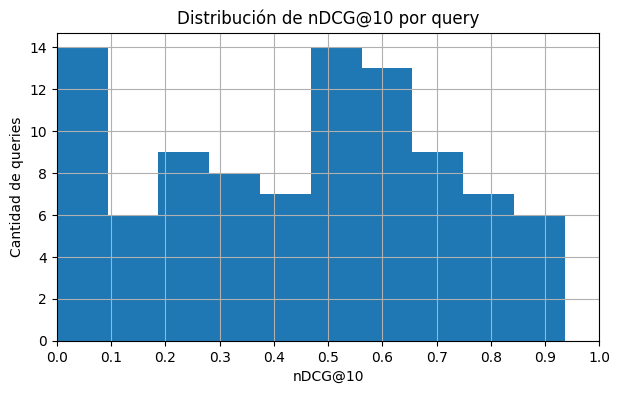

In [17]:
for metric in ["P@10", "AP", "nDCG@10"]:
    plt.figure(figsize=(7, 4))
    plt.hist(eval_by_query[metric].dropna(), bins=10)
    plt.title(f"Distribución de {metric} por query")
    plt.xlabel(metric)
    plt.ylabel("Cantidad de queries")
    plt.xlim(0, 1)
    plt.xticks(np.arange(0, 1.1, 0.1)) # Add x-axis ticks from 0.0 to 1.0 with 0.1 steps
    plt.grid(True)
    plt.show()

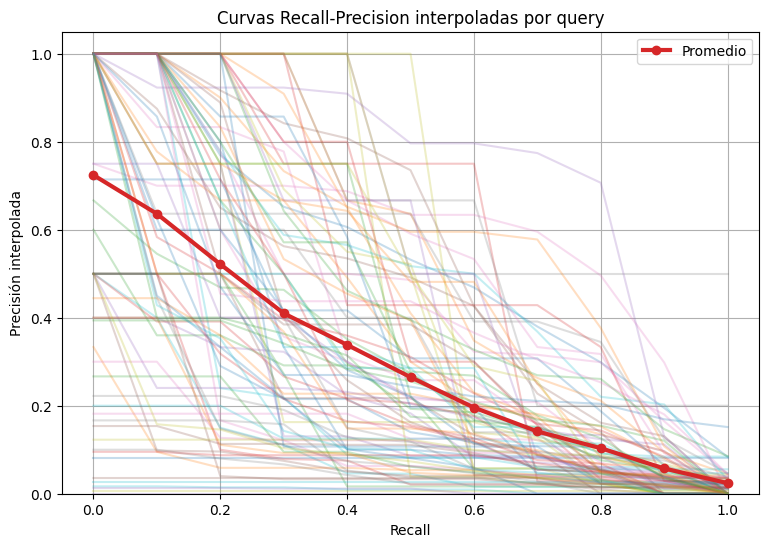

In [18]:
# Grafica 11 niveles estandar
plt.figure(figsize=(9, 6))

for row in eval_by_query.itertuples(index=False):
    y = [getattr(row, col.replace("@", "_").replace(".", "_"), None) for col in []]

# Forma más simple: iterar sobre el DataFrame.
for _, row in eval_by_query.iterrows():
    plt.plot(STANDARD_RECALL_LEVELS, row[rp_cols].values, alpha=0.25)

plt.plot(STANDARD_RECALL_LEVELS, mean_rp.values, marker="o", linewidth=3, label="Promedio")
plt.title("Curvas Recall-Precision interpoladas por query")
plt.xlabel("Recall")
plt.ylabel("Precisión interpolada")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()
